# **Project 2**
## **Sales revenue prediction**

## Introduction

In an increasingly competitive market, understanding the drivers behind sales performance is critical.
This project presents a comprehensive analysis of sales revenue for an e-commerce store over a period of three years (2008 to 2011). By extracting insghts from historical sales data, this analysis aims to inform future marketing startegies and ultimately drive revenue growth. The resulting findings will provide a data-driven framework for optimizing and predicting future sales values and maximizing overall return on investment.


## Data sources, collection method, and population of interest

The population of interest consists of all individual customers who completed a non-refunded transaction. The data was obtained from kaggle via a csv file. The extracted data contains variables such as product price, competition index, seasonality index, market reach, advertisement expenditure, date, applied discount, and more...

To ensure the integrity of the analysis, the raw dataset went through rigorous cleaning and preprocessing using Python to handle any anomalies. Once prepared, these metrics were integrated into a linear regression model to predict future sales values


## Limitations

While the dataset is robust, this analysis is subject to several limitations:

- The data only reflects historical trends up to 2011, meaning that it may not account for recent market changes.

- A portion of the dataset contained null values and outliers, which required imputation, and may potentially reducing the effectiveness of the demographic analysis.

- The dataset deos not capture the broader economic indicators influencing sales revenue.


## Ethical considerations

All data was anonymized prior to extraction to ensure comliance with data privacy regulations and protect personally identifiable information. By adhering to these ethical standards, the study maintains a focus on broad sales activity patterns.

# **Data overview**

The dataset contains eighteen thousands observations spread across 18 variables, with each row representing a transaction. Below is a list of all variables along with their types:

| Column Name | Data Type|
|---|---|
| id | int64 |
| date | object |
| region | object |
| channel | object |
| product_category | object |
| customer_segment | object |
| ad_spend | float64 |
| price | float64 |
| discount_rate | float64 |
| market_reach | float64 |
| impressions | float64 |
| click_through_rate | float64 |
| competition_index | float64 |
| seasonality_index | float64 |
| campaign_duration_days | float64 |
| customer_lifetime_value | float64 |
| sales_revenue | float64 |
| year | int64 |

# **Data analysis**

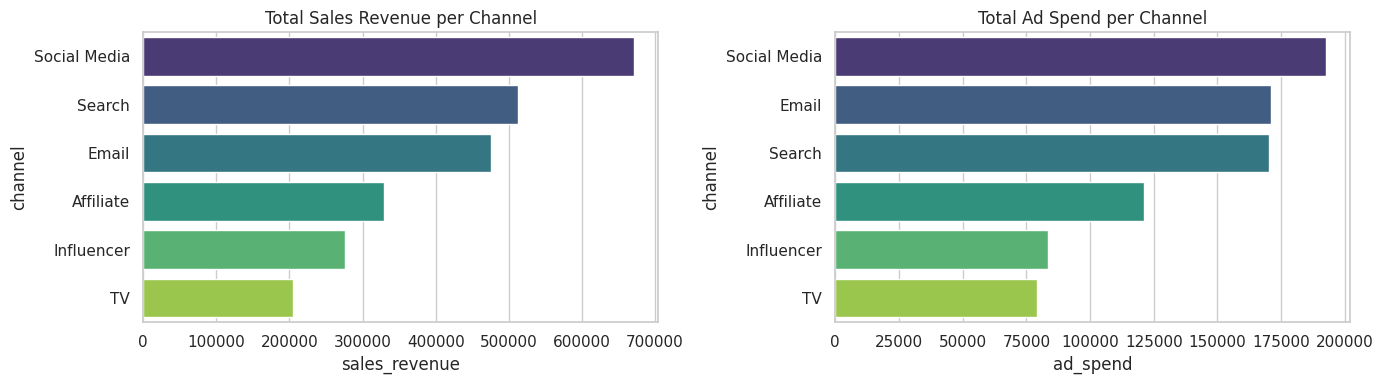

A comparative analysis of channel performance, contrasting total sales revenue and total advertisement expenditure was conducted. Social media emerges as the most dominant channel in both metrics, generating nearly 700,000 dollars in revenue while requiring nearly 200,000 dollars in ads spending. Search and email occupy the second and third positions for revenue, though their ranking is reversed in terms of spending. Overall, the charts indicate a consistent hierarchy where channels with higher advertising budgets correlate with higher total sales revenue.

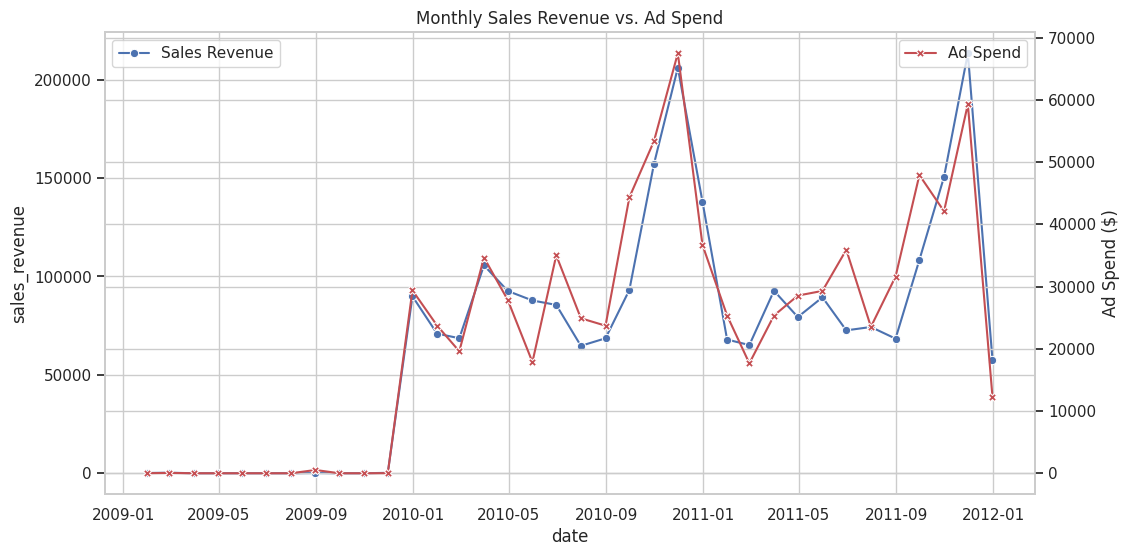


This visual illustrates the dynamic changes between the company's total sales revenue and advertisement expenditures over time. A notable peak occured in late 2010 where an investment of approximately 70,000 dollars in ads triggered an amount of 200,000 dollars in revenue. However, sales revenue reached its highest point in the late 2011 despite the ads expenditure being lower than the previous years. From this visual, some kind of correlation between the two variables can be anticipated since a similar movement is observed all throughout the plot. The two metrics track each other with remarkable synchronicity.

Additionally, Price distribution and ad spend are both right skewed with most observations concentrated amnong the lowest values. Though right-skewed, market reach shows a more gradual profile. The Clock through rate is also right skewed, with most campaigns achieving a rate below 0.1, though a few reached 0.3. Furthermore, the campaign duration distribution is multimodal, showing distinct clusters of campaigns lasting approximately 10 to 60 days.

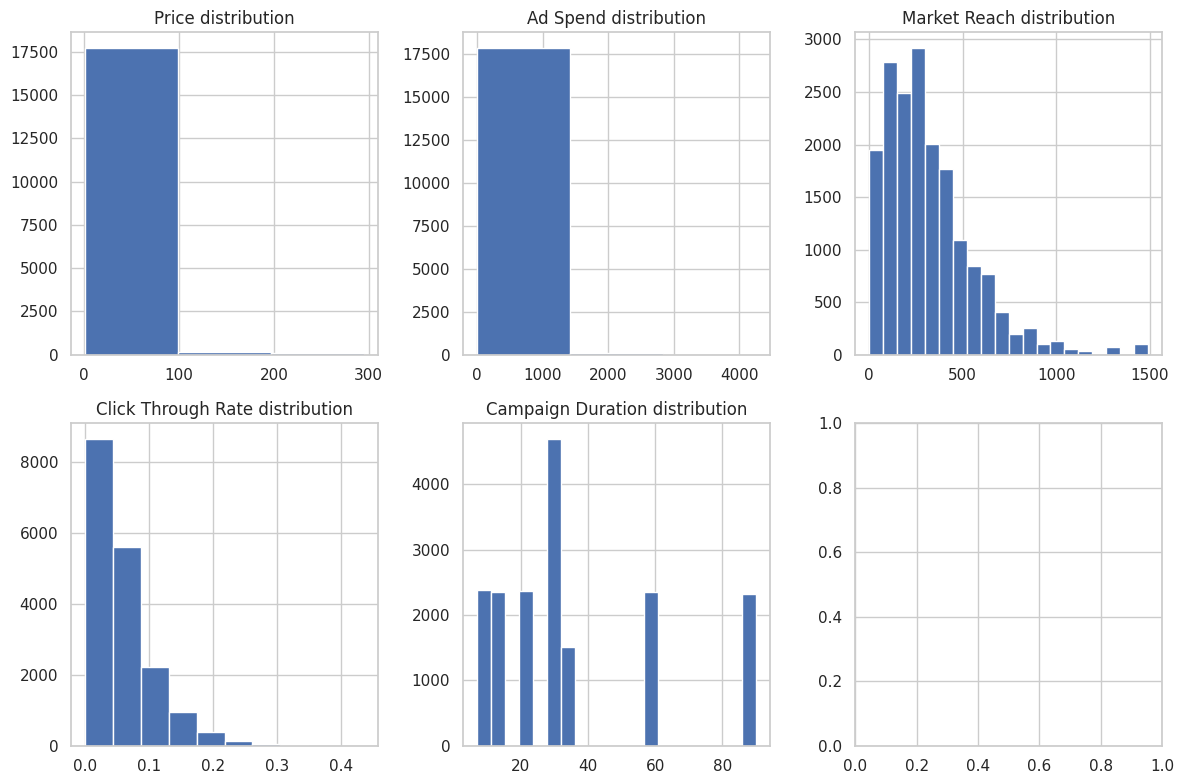

This serie of scatter plots visualizes the relationship between several variables. The data points are primarily concentrated at the lower end of the respective scales, indicating that a vast majority of transactions result in lower revenue revenue outcomes regardless of metrics. The campaign duration plot displays a distinct pattern with data points clustered at specific intervals.

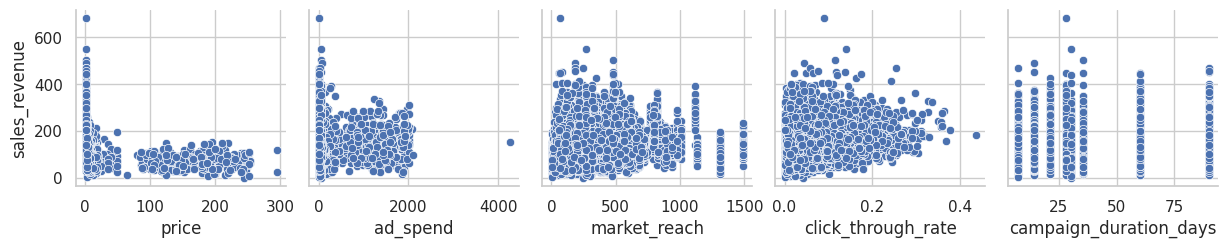

# **Modeling**

Feature	    Coefficient

	click_through_rate	0.097173
	campaign_duration_days	0.082223
	market_reach	0.066485
	impressions	0.059488
	customer_lifetime_value	0.039567
	ad_spend	-0.016250
  discount_rate 	-0.053368

	price	-0.142405


The predictive analysis used a linear regression model to predict future sales revenue. Before fitting the model, a substantial amount of data preprocessing was performed to prepare the features for training. The raw data was aggregated to capture the values for each day. Following this, several time-based features were extracted to capture temporal patterns. Moreover, lagged features were engineered to capture values for the previous day(lag1), values for the past seven days(lag7). Also, rolling values were engineered to reveal the average sale over the past seven and thirty days(revenue_roll7 & revenue_roll30). These are vital for a time_series analysis, for they help include the past performance into future prediction.
Two models were developed. Both models were evaluated using metrics such as r_squared, mean squared error, root mean squared error, and mean absolute error. The first model return an r_squared of 0.05, which indicates that the features could only predict five percent of the variance in sales revenue. With an average absolute difference of 100.21, the model  revealed a high magnitude of between error in the set of prediction. With very large MSE and RMSE, respectively, 18395.21 and 135.63, the model failed to effectively predict future sales revenue.

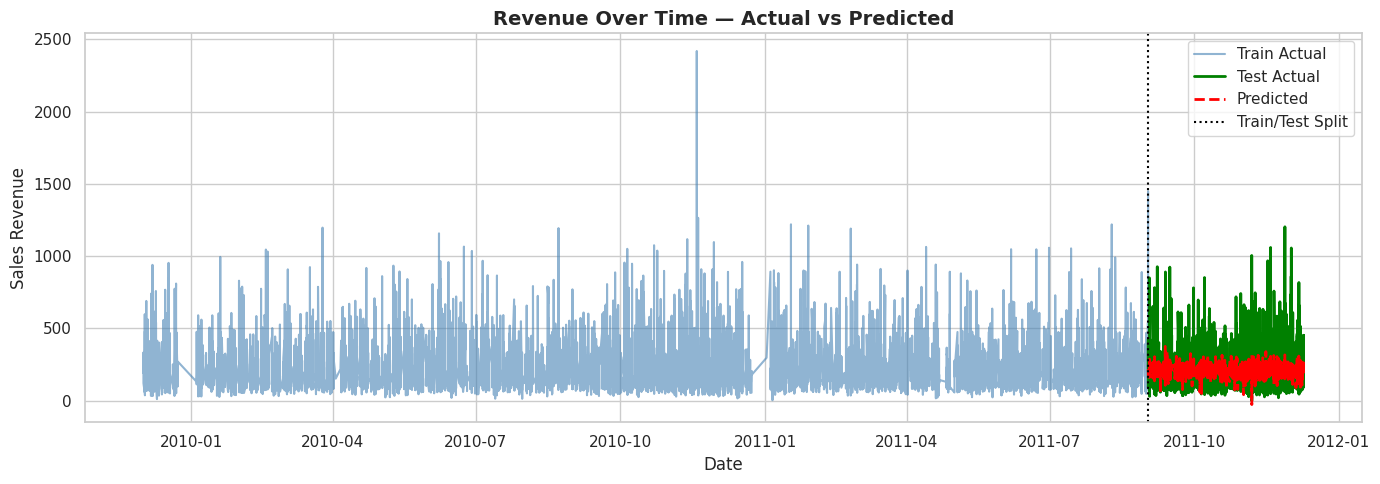

As observed on the following graph, the model captures the baseline of sales rather than the high frequency present in the data. It failed to anticipate the spike observed in both train and test data. This suggests that while the model understands the general trend, it struggles to account for the specific exogenous variables or seasonal anomalies that drive short-term volatility.

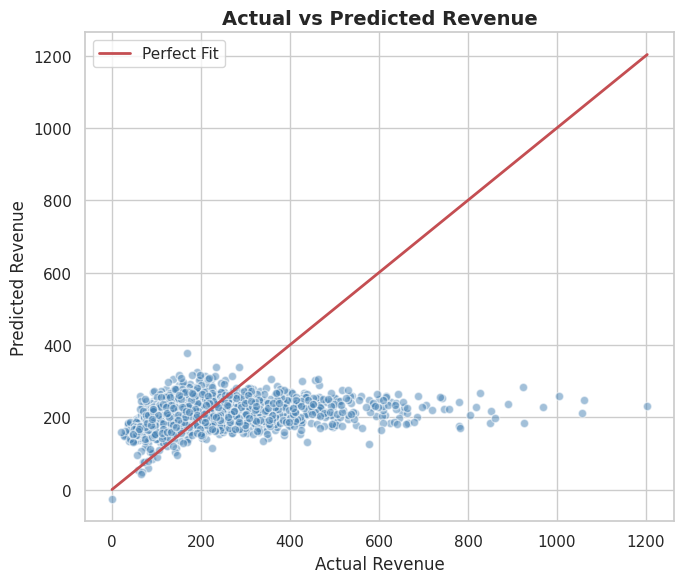

This scatter plot confirms the pattern of underprediction. While the model maitained proximity with the perfect fit line at the low revenue level, the data points diverge as revenue increases. The visual reinforces the earlier observation that the model captures the baseline tendencyof the distribution. As actual revenue leans toward 1200, the predicted values remain stagnant between 200 and 300. The significant variance at these higher thresholds indicates that the current features lack the predictive power necessary to scale with rapid revenue growth.

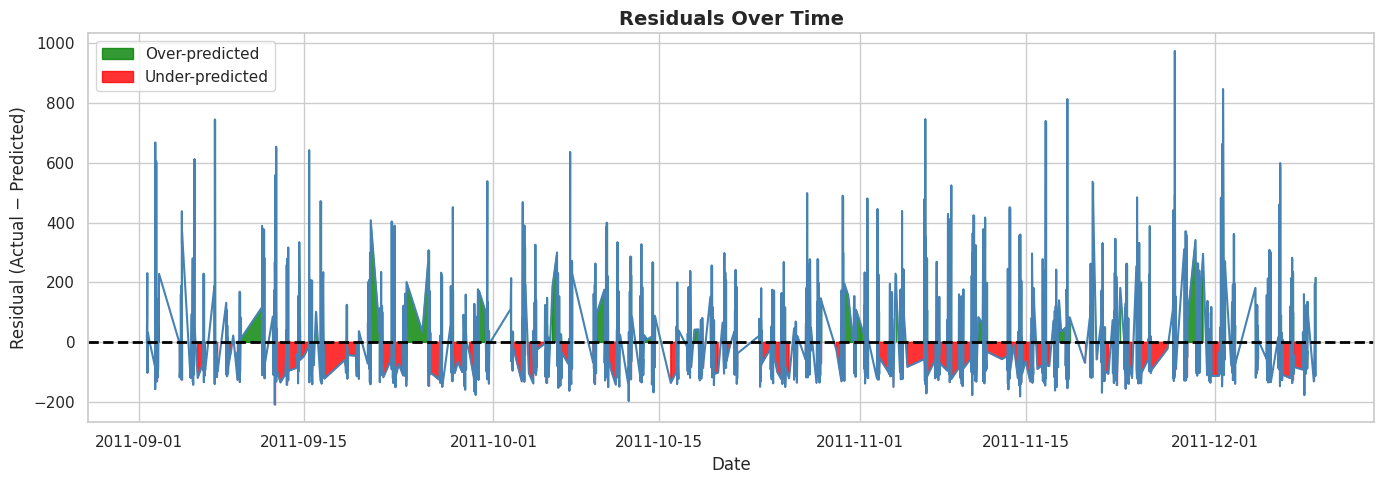

The residuals, which are the differences between actual and predicted values, frequently spike into positive space, meaning the actual sales were much higher than the what the model forecasted, which again confirm the ceiling effect noted above.

To improve performance, a log transformation was applied. As observed above, variables like price and ad_spend are heavily clustered at the lower values. By applying a log transformation, extreme values will be pulled closer to the the mean, which would diminish skewness and result in a more normal distribution, satisfying the assumption of a linear distribution. Therefore, the model would be able to capture the shifts more accurately.

Following the transformation, the model return a r_squared of 0.10. The increase in the r_squared suggests that normalizing the skewed distribution allowed the model to capture much of the underlying relationship between the variables. Furthermore, the new model return a mean squared error of0.33. The significant reduction of the MSE indicates that the transformation stabilized the the variance.

The log-transformed model is the better performer, considering the augmentation in the r-squared value form .05 to .10. This improvement stems from the transformation's ability to normalize the heavily skewed distribution of variable slike price and ad spend. By compressing the scale of these features, the model is better equipped to handle the relationships in e-commerce metrics. This adjustment effectively stabilizes the variance of the residuals and provides a more mathematical foundation for interpreting how marketing investments correlate with revenue outcomes.

The price variable has the strongest negative impact (-0.142), indicating that higher price reduce sales volume. interestingly, ad_spend (-0.016) and discount_rate (-0.053) also show negative effects. On the other hand, click through rate and campaign duration are the most significant drivers of sales revenue. Overall, the coefficients indicate that while expanding market reach and impression support growth, the model is heavily impacted by the negative pressure of pricing and expenditures.

## Predicting three new data points

new_data_points

    'ad_spend': [50, 100, 20],
    'price': [5, 7, 3],          
    'discount_rate': [0.25, 0.15, 0.35],
    'market_reach': [300, 500, 100],
    'impressions': [8000, 15000, 4000],
    'click_through_rate': [0.06, 0.1, 0.03],
    'campaign_duration_days': [40, 60, 20],
    'customer_lifetime_value': [10000, 20000, 5000]


Predicted Sales Revenue

	898.420580
	1724.355245
	448.458775

# **Conclusion**

In conclusion, the predictive modeling process demonstrates that the log-transformed model is significantly more effective than the baseline version, effectively doubling the explanatory power by increasing the R-squared from 0.05 to 0.10. By addressing the extreme right-skewness observed in the initial distribution of features like price and advertising investment, the transformation successfully mitigated the "ceiling effect" that previously caused the model to consistently under-predict high-revenue events. The dramatic reduction in Mean Squared Error from 18,395.21 to 0.33 further confirms that stabilizing the variance allows for a much more accurate capture of non-linear relationships. Moving forward, the negative coefficients for price and ad_spend suggest a high degree of price sensitivity and a point of diminishing returns in marketing, indicating that future growth strategies should prioritize high-engagement drivers like click_through_rate and campaign_duration to maximize revenue impact.

To maximize performance, the log_transformed model should eb prioritized since it provides a more accurate foundation. Also, the data suggests that we refrain from increasing raw advertisement expenditures, which shows sign of diminishing returns based on its coefficient. Given the negative impact of price, it is recommended that price be adjusted to match the high price sensitivity observed. Also, a follow up with an analysis of socio-economic data is suggested to integrate the  other factors driving sales revenue